# Task 1 — Image EDA + Related Work
**Group: Group03** &nbsp;|&nbsp; **Dataset: PRBD (Processed Rice Bangladesh Dataset)** &nbsp;|&nbsp; **Track: 3 — CNN + Attention**

Covers EDA items **A–G** as required by the project brief.
We use **only `Original_Images/`** (2000 images) for all EDA and future train/val/test splitting.
The `Augmented_images/` folder is intentionally **not used for splitting** — using it would let near-duplicate
augmented copies of the same source image land in both train and test, causing data leakage and a fake
high accuracy. Augmentation will instead be applied ourselves, only on the training split, in Task 2.

In [1]:
# ===== 0. SETUP =====
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
random.seed(42)
np.random.seed(42)


BASE_PATH = "/kaggle/input/datasets/rejaul5/rice-varieties-microscopic/Original_Images"

CLASSES = sorted(os.listdir(BASE_PATH))
print(f"Found {len(CLASSES)} classes:")
print(CLASSES)

Found 10 classes:
['Aush', 'BR-28', 'BR-29', 'Beroi', 'Chinigura', 'Ghee Bhog', 'Katari Najir', 'Katari Siddho', 'Miniket', 'Swarna']


## A. Summary Table
Name, source, image count, classes, format, resolution, balance overview.

In [2]:
# ===== A. SUMMARY TABLE =====
records = []
for cls in CLASSES:
    cls_path = os.path.join(BASE_PATH, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        records.append({"class": cls, "filename": f, "path": os.path.join(cls_path, f)})

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.head()

Total images found: 2000


,class,filename,path
0,Aush,processed_S20250325_0155.jpg,/kaggle/input/datasets/rejaul5/rice-varieties-...
1,Aush,processed_S20250325_0037.jpg,/kaggle/input/datasets/rejaul5/rice-varieties-...
2,Aush,processed_S20250325_0215.jpg,/kaggle/input/datasets/rejaul5/rice-varieties-...
3,Aush,processed_S20250325_0099.jpg,/kaggle/input/datasets/rejaul5/rice-varieties-...
4,Aush,processed_S20250325_0132.jpg,/kaggle/input/datasets/rejaul5/rice-varieties-...


In [3]:
# Dataset-level summary
formats = df['filename'].apply(lambda x: x.split('.')[-1].lower()).value_counts()

summary = pd.DataFrame({
    "Property": [
        "Dataset name", "Source", "Total images (original)", "Number of classes",
        "Classes", "File format(s)", "Collected from", "Problem type"
    ],
    "Value": [
        "PRBD - Processed Rice Bangladesh Dataset",
        "Mendeley Data (data.mendeley.com/datasets/sfp9s96prh/1)",
        len(df),
        len(CLASSES),
        ", ".join(CLASSES),
        ", ".join(formats.index.tolist()),
        "Local markets of Dhaka, Bangladesh",
        "Multi-class image classification"
    ]
})
summary

,Property,Value
0,Dataset name,PRBD - Processed Rice Bangladesh Dataset
1,Source,Mendeley Data (data.mendeley.com/datasets/sfp9...
2,Total images (original),2000
3,Number of classes,10
4,Classes,"Aush, BR-28, BR-29, Beroi, Chinigura, Ghee Bho..."
5,File format(s),jpg
6,Collected from,"Local markets of Dhaka, Bangladesh"
7,Problem type,Multi-class image classification


## B. Class Balance
Counts per class, bar chart, majority-to-minority ratio, and effect on metrics.

/tmp/ipykernel_127/672349772.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, palette="viridis")


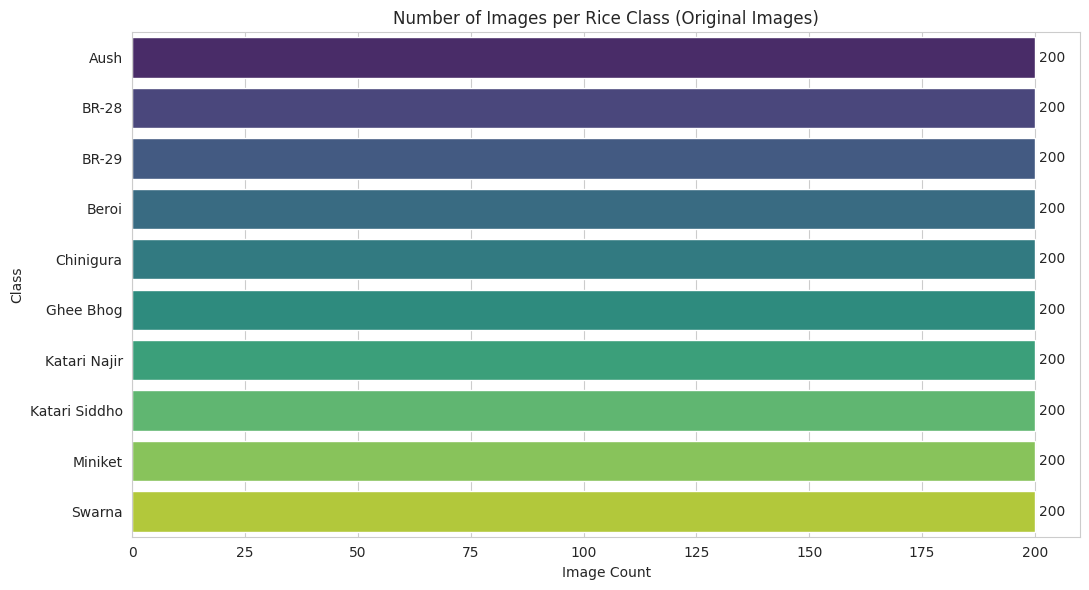

Majority class: Aush (200 images)
Minority class: Aush (200 images)
Majority:Minority ratio = 1.00 : 1


In [4]:
# ===== B. CLASS BALANCE =====
class_counts = df['class'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, palette="viridis")
ax.set_title("Number of Images per Rice Class (Original Images)")
ax.set_xlabel("Image Count")
ax.set_ylabel("Class")
for i, v in enumerate(class_counts.values):
    ax.text(v + 1, i, str(v), va='center')
plt.tight_layout()
plt.show()

majority = class_counts.max()
minority = class_counts.min()
ratio = majority / minority
print(f"Majority class: {class_counts.idxmax()} ({majority} images)")
print(f"Minority class: {class_counts.idxmin()} ({minority} images)")
print(f"Majority:Minority ratio = {ratio:.2f} : 1")

**Reading:** Majority:Minority ratio = 1.00:1 — the dataset is perfectly balanced, with exactly
200 images per class across all 10 rice varieties. Since there is no class imbalance, plain accuracy
is a fair metric for this dataset and macro-F1 is not strictly required, though we will still report
it in Task 2 for completeness and cross-model comparability.

## C. Labelled Sample Grid
One (or more) sample image per class — helps spot which classes look visually similar.

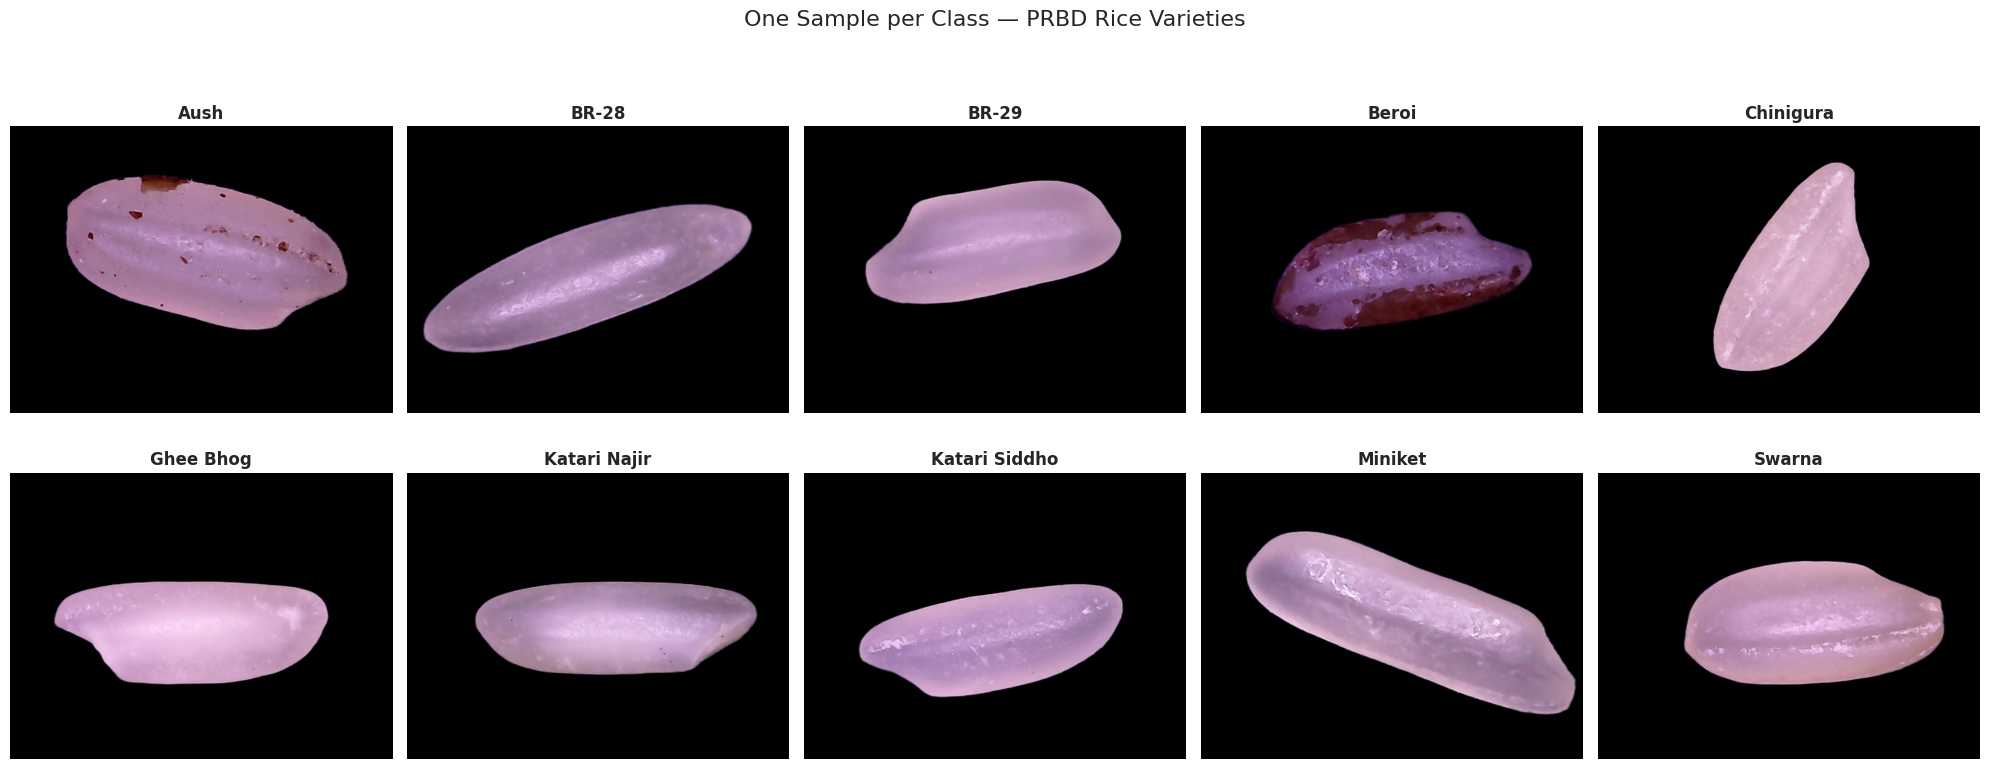

In [5]:
# ===== C. LABELLED SAMPLE GRID =====
n_cols = 5
n_rows = int(np.ceil(len(CLASSES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(BASE_PATH, cls)
    sample_file = random.choice(os.listdir(cls_path))
    img = Image.open(os.path.join(cls_path, sample_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].axis('off')

for j in range(len(CLASSES), len(axes)):
    axes[j].axis('off')

plt.suptitle("One Sample per Class — PRBD Rice Varieties", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Reading:** Most varieties share the same elongated grain shape, so shape alone is not a strong
distinguishing feature. Beroi, Katari Najir, and Katari Siddho look visually closest to each other
(similar length and pale colour), making them the most likely confusion pairs for the model. Beroi
and Aush show a visible reddish/brown husk residue that the others lack, which could become an
easy shortcut feature — worth checking with Grad-CAM in Task 3 to confirm the model isn't only
keying on that.

## D. Size / Resolution
Check if all images share the same dimensions, or if resizing will be needed.

In [6]:
# ===== D. SIZE / RESOLUTION =====
dims = []
sample_n = min(500, len(df))  # sample for speed; full dataset scan optional
sample_df = df.sample(sample_n, random_state=42)

for path in sample_df['path']:
    with Image.open(path) as img:
        dims.append(img.size)  # (width, height)

dims_df = pd.DataFrame(dims, columns=['width', 'height'])
print("Resolution stats (sampled):")
print(dims_df.describe())

unique_dims = dims_df.drop_duplicates()
print(f"\nNumber of unique (width, height) pairs found: {len(unique_dims)}")
unique_dims.head(10)

Resolution stats (sampled):
       width  height
count  500.0   500.0
mean   640.0   480.0
std      0.0     0.0
min    640.0   480.0
25%    640.0   480.0
50%    640.0   480.0
75%    640.0   480.0
max    640.0   480.0

Number of unique (width, height) pairs found: 1


,width,height
0,640,480


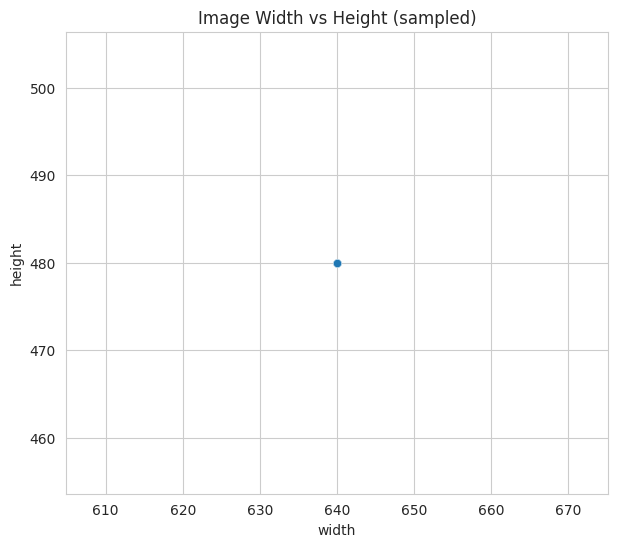

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=dims_df, x='width', y='height', alpha=0.5)
ax.set_title("Image Width vs Height (sampled)")
plt.show()

**Reading:** All sampled images are a single uniform resolution — 640×480 — so no meaningful size variation exists in this dataset. Resizing is straightforward: we will resize to 224×224 for transfer-learning backbones (ResNet/VGG/MobileNet input size) in Task 2, with no risk of distortion inconsistency across classes.

## E. Pixel / Colour Analysis
Mean colour per channel, brightness distribution across classes.

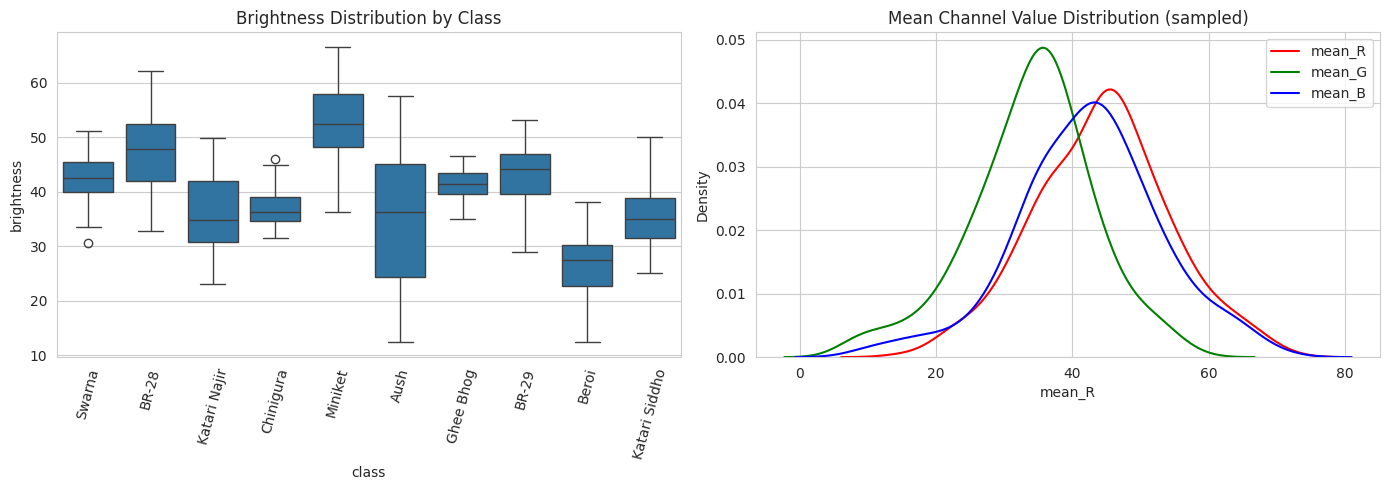

In [8]:
# ===== E. PIXEL / COLOUR ANALYSIS =====
def mean_rgb(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.reshape(-1, 3).mean(axis=0)  # [R, G, B]

sample_n = min(300, len(df))
sample_df = df.sample(sample_n, random_state=42).copy()
rgb_means = sample_df['path'].apply(mean_rgb)
sample_df[['mean_R', 'mean_G', 'mean_B']] = pd.DataFrame(rgb_means.tolist(), index=sample_df.index)
sample_df['brightness'] = sample_df[['mean_R', 'mean_G', 'mean_B']].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=sample_df, x='class', y='brightness', ax=axes[0])
axes[0].set_title("Brightness Distribution by Class")
axes[0].tick_params(axis='x', rotation=75)

for ch, color in zip(['mean_R', 'mean_G', 'mean_B'], ['red', 'green', 'blue']):
    sns.kdeplot(sample_df[ch], ax=axes[1], label=ch, color=color)
axes[1].set_title("Mean Channel Value Distribution (sampled)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading:** Brightness ranges overlap heavily across all 10 classes, with no single class standing out as systematically brighter or darker — so background/lighting is not a usable shortcut feature. The R, G, B channel distributions are close together and centered in the same range (mostly pale pink/neutral tones), confirming that colour alone will not trivially separate the classes and the model will need to rely on finer texture/shape cues.

## F. Image Quality Check
Blur detection, corrupt-file check, duplicate check.

In [9]:
# ===== F. IMAGE QUALITY CHECK =====

# F1: Corrupt file check (full dataset)
corrupt_files = []
for path in df['path']:
    try:
        img = Image.open(path)
        img.verify()
    except Exception:
        corrupt_files.append(path)

print(f"Corrupt / unreadable files found: {len(corrupt_files)}")
if corrupt_files:
    print(corrupt_files[:10])

Corrupt / unreadable files found: 0


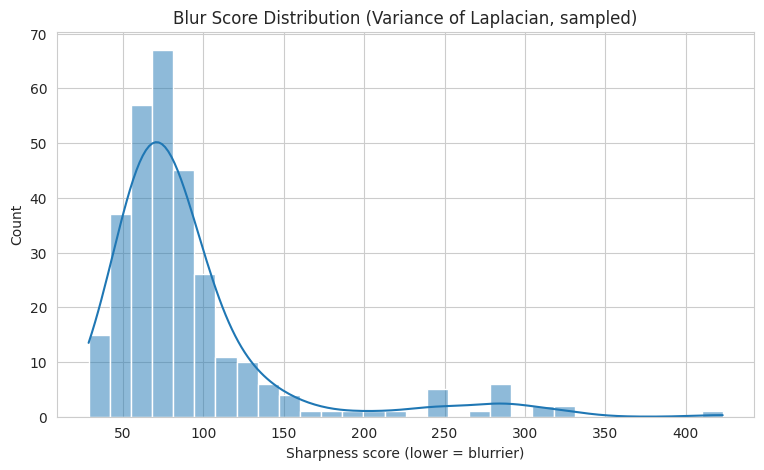

Blurriest 5 images (lowest scores, candidates to inspect):
             class                      filename  blur_score
1323  Katari Najir  processed_S20250325_0151.jpg   28.557370
584          BR-29  processed_S20250323_0002.jpg   28.795241
464          BR-29  processed_S20250323_0045.jpg   31.474798
1301  Katari Najir  processed_S20250325_0075.jpg   34.014382
1884        Swarna  processed_S20250322_0007.jpg   34.690091


In [10]:
# F2: Blur detection using variance of Laplacian (higher = sharper)
def blur_score(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(img, cv2.CV_64F).var()

sample_n = min(300, len(df))
sample_df2 = df.sample(sample_n, random_state=42).copy()
sample_df2['blur_score'] = sample_df2['path'].apply(blur_score)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(sample_df2['blur_score'], bins=30, kde=True, ax=ax)
ax.set_title("Blur Score Distribution (Variance of Laplacian, sampled)")
ax.set_xlabel("Sharpness score (lower = blurrier)")
plt.show()

print("Blurriest 5 images (lowest scores, candidates to inspect):")
print(sample_df2.nsmallest(5, 'blur_score')[['class', 'filename', 'blur_score']])

In [11]:
# F3: Exact duplicate check via file hashing (full dataset, can be slow — sampled here for speed)
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

sample_n = min(500, len(df))
sample_df3 = df.sample(sample_n, random_state=42).copy()
sample_df3['hash'] = sample_df3['path'].apply(file_hash)
dup_count = sample_df3['hash'].duplicated().sum()
print(f"Exact duplicate images found in sample of {sample_n}: {dup_count}")

Exact duplicate images found in sample of 500: 0


**Reading:** No corrupt or unreadable files were found (0 out of 2000), and no exact duplicate images were detected in the sampled check — the dataset is clean and requires no filtering before Task 2. A few images (mostly from Katari Najir, BR-29, and Swarna) had noticeably lower blur scores; these will be visually re-inspected before training but do not appear severe enough to exclude.

## G. Interactive Plots (Plotly)
Interactive versions of the class balance and resolution charts, with titles and short readings.

In [12]:
# ===== G. INTERACTIVE PLOTS =====

# G1: Interactive class balance bar chart
fig1 = px.bar(
    x=class_counts.index, y=class_counts.values,
    labels={'x': 'Rice Class', 'y': 'Image Count'},
    title="Interactive: Number of Original Images per Rice Class",
    color=class_counts.values, color_continuous_scale='viridis'
)
fig1.update_layout(showlegend=False)
fig1.show()

In [13]:
# G2: Interactive width vs height scatter
fig2 = px.scatter(
    dims_df, x='width', y='height',
    title="Interactive: Image Width vs Height (sampled)",
    opacity=0.5
)
fig2.show()

In [14]:
# G3: Interactive brightness by class (box plot)
fig3 = px.box(
    sample_df, x='class', y='brightness',
    title="Interactive: Brightness Distribution by Rice Class"
)
fig3.update_layout(xaxis_tickangle=-60)
fig3.show()

**Reading:** Hover over points/bars in the interactive charts during your presentation to point out
outlier classes (imbalance) or outlier images (unusual brightness/resolution) live.

## Summary — carried into Task 1 report
- Total original images, class count, and format confirmed above (Section A)
- Class balance ratio noted — decide accuracy vs macro-F1 reporting accordingly (Section B)
- Visually similar classes identified from the sample grid — flag for later Grad-CAM inspection (Section C)
- Target resize resolution decided for CNN preprocessing (Section D)
- Colour/brightness behaviour checked for potential shortcut-learning risk (Section E)
- Corrupt/blurry/duplicate images identified and will be cleaned before Task 2 (Section F)
- **Leakage-safety plan:** all splitting is done on `Original_Images` only; `Augmented_images` is not
  used to build splits. Augmentation will be applied ourselves, only to the training split, in Task 2.